# SARIMA Model for Energy Price in Spain
A SARIA model will be used to create a benchmark for energy price, similarly to how we previously predicted enegy demand in [SARIMA_demand.ipynb](SARIMA_demand.ipynb).

A SARIMA model (Seasonal AutoRegressive Integrated Moving Average) is a type of time series forecasting model that extends ARIMA by incorporating seasonality. It’s effective for data with patterns repeating at regular intervals, like the weekly pattern in energy demand. This model will act as a benchmark for more complex ML models.

## SARIMA Components:
SARIMA is defined by the parameters: (p, d, q) × (P, D, Q, s), where:

- Non-Seasonal Components (ARIMA part):
    - p (Auto-Regressive order): Number of past observations to use for predicting future values (lagged terms).
    - d (Differencing order): Number of times the data needs to be differenced to make it stationary.
    - q (Moving Average order): Number of lagged forecast errors to include in the model.
- Seasonal Components:
    - P (Seasonal Auto-Regressive order): Number of seasonal lags (e.g., past seasons) to include for prediction.
    - D (Seasonal Differencing order): Number of seasonal differences to make the data stationary for seasonal patterns.
    - Q (Seasonal Moving Average order): Number of seasonal lagged forecast errors to include.
    - s (Seasonal period): Number of time steps in a season (e.g., 24 for hourly data with daily seasonality).

## Energy Demand Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
import pmdarima
from scipy.stats import probplot
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv('data/energyPrice.csv')
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df.set_index('datetime', inplace=True)

df.describe()

,Energy Price (EUR/MWh)
count,43849.000000
mean,90.367774
std,70.501039
min,-2.000000
25%,37.070000
50%,76.730000
75%,125.610000
max,700.000000


<Axes: >

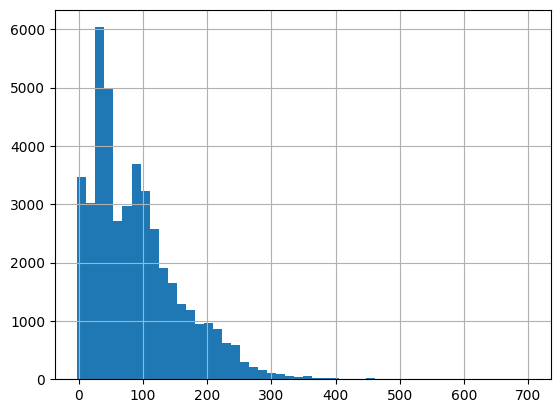

In [3]:
df['Energy Price (EUR/MWh)'].hist(bins=50)

This shows that energy price follows a non-Gaussian, heavy-tailed distribution with right-skewness, probably due to extreme price spikes that can be seen below.

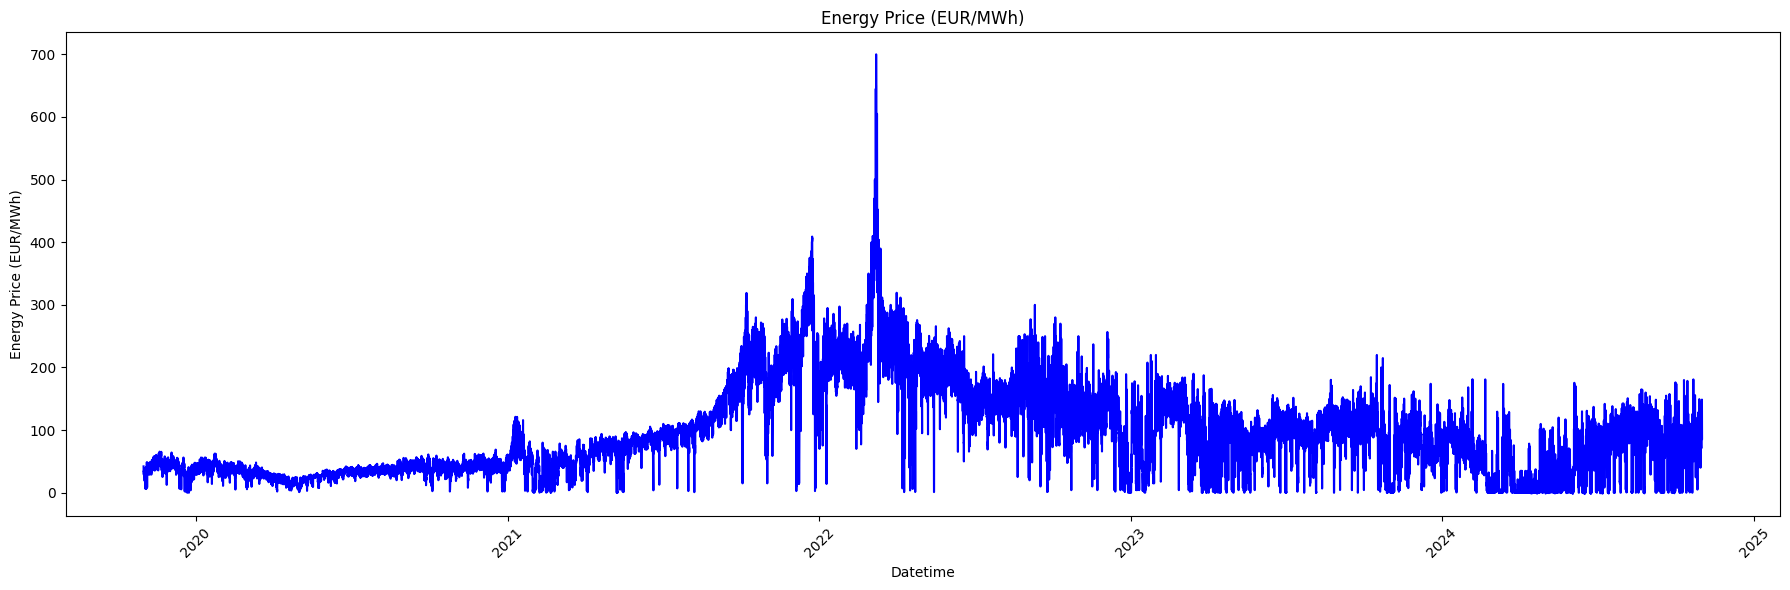

In [4]:
plt.figure(figsize=(18, 6))
plt.plot(df['Energy Price (EUR/MWh)'], linestyle='-', color='b')

plt.title('Energy Price (EUR/MWh)')
plt.xlabel('Datetime')
plt.ylabel('Energy Price (EUR/MWh)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Seasonsal Periods

Breaking down the data into `Observed=Trend+Seasonality+Residual` helps visualise any seasonality. Hourly, weekly and yearly seasonality will be considered.

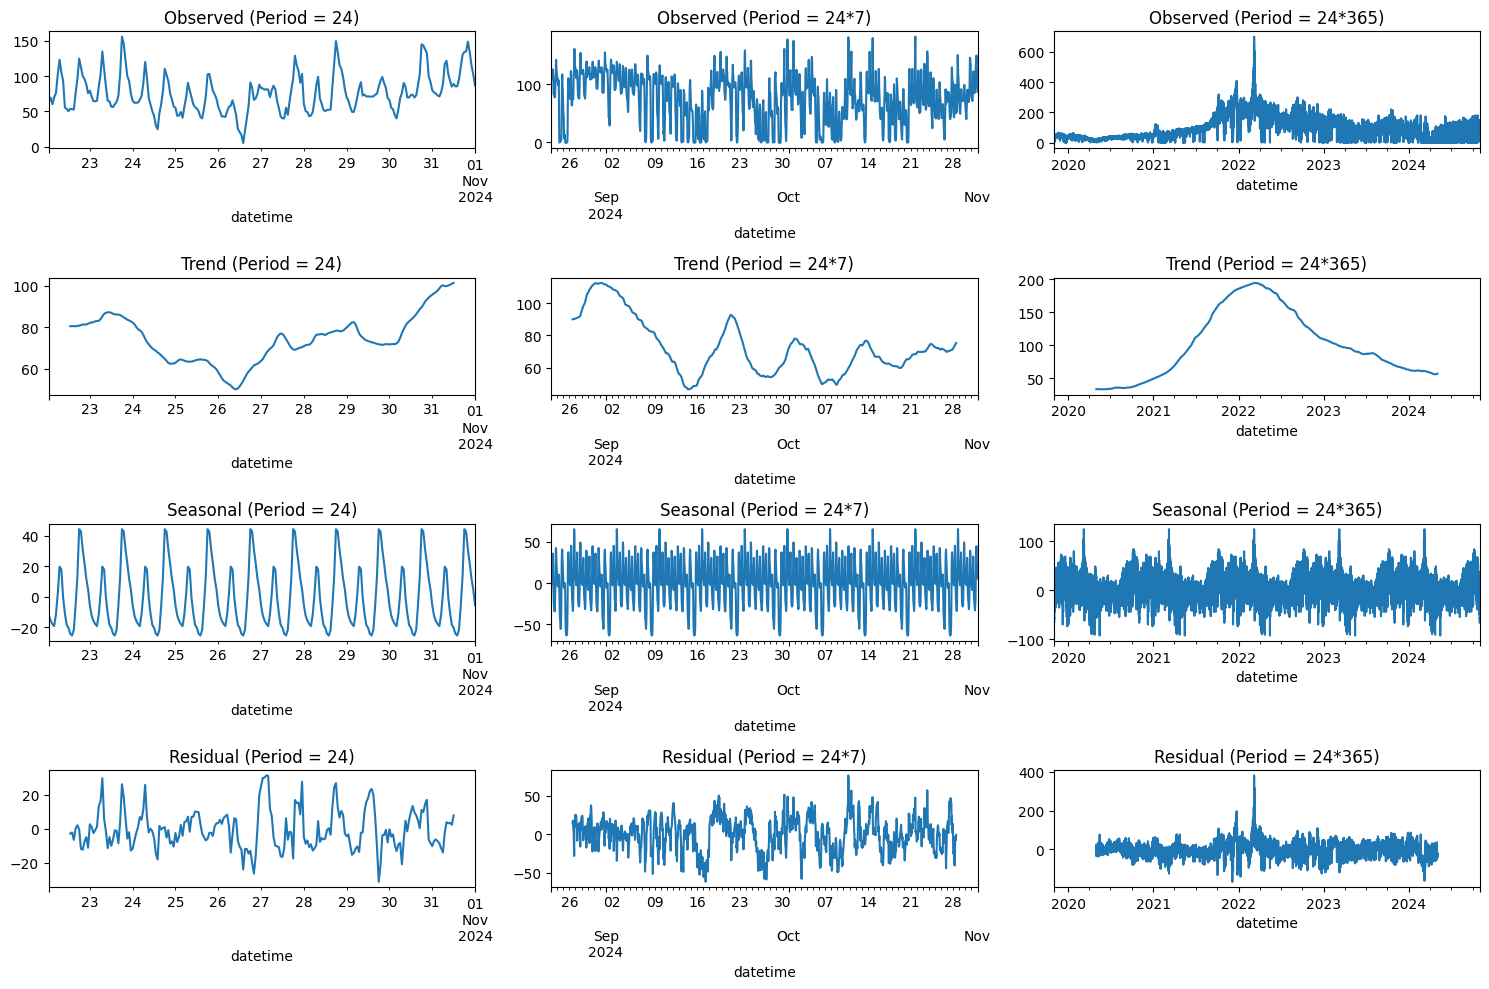

In [5]:
fig, axes = plt.subplots(4, 3, figsize=(15, 10))

# Decompose the data with different periods
result_24 = sm.tsa.seasonal.seasonal_decompose(df['Energy Price (EUR/MWh)'][-240:], model='additive', period=24)
result_24_7 = sm.tsa.seasonal.seasonal_decompose(df['Energy Price (EUR/MWh)'][-1680:], model='additive', period=24*7)
result_24_365 = sm.tsa.seasonal.seasonal_decompose(df['Energy Price (EUR/MWh)'], model='additive', period=24*365)

# Plot for Period = 24
result_24.observed.plot(ax=axes[0, 0], title='Observed (Period = 24)')
result_24.trend.plot(ax=axes[1, 0], title='Trend (Period = 24)')
result_24.seasonal.plot(ax=axes[2, 0], title='Seasonal (Period = 24)')
result_24.resid.plot(ax=axes[3, 0], title='Residual (Period = 24)')
# Plot for Period = 24*7
result_24_7.observed.plot(ax=axes[0, 1], title='Observed (Period = 24*7)')
result_24_7.trend.plot(ax=axes[1, 1], title='Trend (Period = 24*7)')
result_24_7.seasonal.plot(ax=axes[2, 1], title='Seasonal (Period = 24*7)')
result_24_7.resid.plot(ax=axes[3, 1], title='Residual (Period = 24*7)')

# Plot for Period = 24*365
result_24_365.observed.plot(ax=axes[0, 2], title='Observed (Period = 24*365)')
result_24_365.trend.plot(ax=axes[1, 2], title='Trend (Period = 24*365)')
result_24_365.seasonal.plot(ax=axes[2, 2], title='Seasonal (Period = 24*365)')
result_24_365.resid.plot(ax=axes[3, 2], title='Residual (Period = 24*365)')

plt.tight_layout()
plt.show()

This allows for a clear view of daily, weekly and yearly seasonality. For an ARIMA model for hourly data, yearly seasonality won't be captured because the window of lagged terms will not be sufficiently large. Therefore, for this benchmark model, yearly seasonality will be ignored. 

Importantly, there are still large values for the hourly and weekly residuals, suggesting the models haven't successfully captured most aspects of the data. These residuals are likely largely explained by variation in energy production and gas price.

To capture a better of view of hourly and weekly seasonality either a shorter period of data must be used, or a mean must be taken.

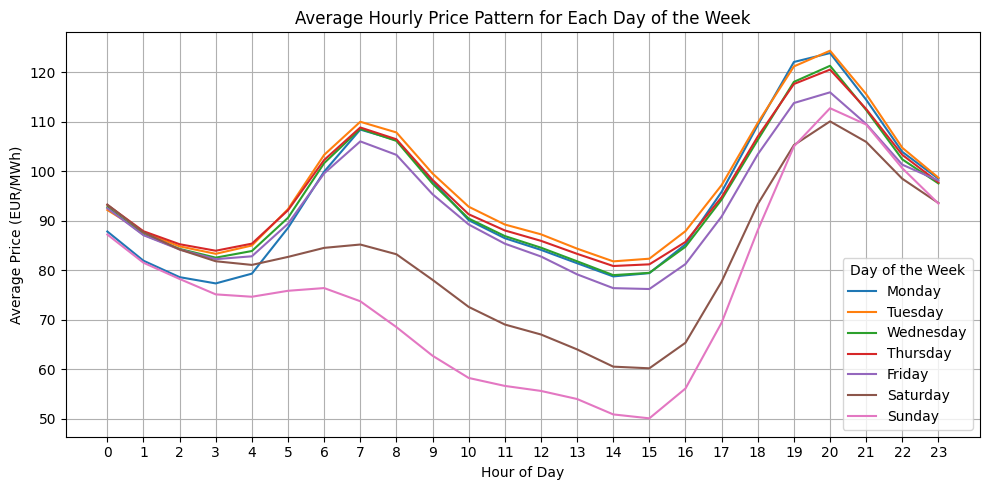

In [6]:
df['day_of_week'] = df.index.dayofweek  # Monday=0, Sunday=6
df['hour'] = df.index.hour

# Group by day of the week and hour, then calculate the mean
weekly_pattern = (
    df.groupby(['day_of_week', 'hour'])['Energy Price (EUR/MWh)']
    .mean()
    .reset_index()
)

# Create a pivot table for easier plotting
pivot = weekly_pattern.pivot(index='hour', columns='day_of_week', values='Energy Price (EUR/MWh)')

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 5))

for day_idx, day in enumerate(days):
    plt.plot(pivot.index, pivot[day_idx], label=day)

plt.title('Average Hourly Price Pattern for Each Day of the Week')
plt.xlabel('Hour of Day')
plt.ylabel('Average Price (EUR/MWh)')
plt.xticks(range(0, 24), labels=range(0, 24))
plt.legend(title='Day of the Week')
plt.grid()

plt.tight_layout()
plt.show()

This shows a clear daily repeating pattern that the SARIMA model should capture. This also shows a weekly seasonality, with lower energy price on Saturday and Sunday, and since an SARIMA model only allows for one seasonal period, we will model for a weekly trend as this will also capture the daily trend. It is possible to incorporate multiple trends, i.e. daily, into a model of this kind by using a SARIMAX model, which allows the inclusion of exogenous variables (external predictors) to improve the model. In this case, Fourier terms for additional seasonalities would be treated as exogenous variables. However, since this model is going to act as a benchmark we want to keep it as simple as possible.

**Therefore, in this model s = 24*7 = 168**

## Stationarity

A SARIMA model assumes stationarity because it relies on constant statistical properties (mean, variance, and autocorrelation) to accurately model relationships and forecast future values. Non-stationary data can lead to misleading results as the model cannot properly account for time-dependent changes in the data.

However, SARIMA models can handle non-stationary time series by incorporating differencing parameters (d for trend differencing and D for seasonal differencing) to transform the series into a stationary one.

### Augmented Dickey-Fuller (ADF) test

The ADF test is a statistical test used to determine whether a given time series is stationary or has a unit root (non-stationary). Its hypotheses are the following:

 - Null Hypothesis  H0 : The time series has a unit root, meaning the series is non-stationary (it has a trend or random walk behavior).
 - Alternate Hypothesis  H1 : The time series has no unit root and is either stationary or can be made stationary using differencing.

By default `statsmodels.tsa.stattools.adfuller` uses Schwarz Information Criterion (SIC) to select the optimal number of lags. 

In [7]:
adf_test = sm.tsa.stattools.adfuller(df['Energy Price (EUR/MWh)'])
print(f'ADF Statistic: {adf_test[0]:.6f}\n'
    f'p-value: {adf_test[1]:.6f}\n'
    f'#Lags used: {adf_test[2]}')

for key, value in adf_test[4].items():
    print(f'Critical Value ({key}): {value:.6f}')

ADF Statistic: -6.223984
p-value: 0.000000
#Lags used: 54
Critical Value (1%): -3.430499
Critical Value (5%): -2.861606
Critical Value (10%): -2.566805


The ADF statistic (-6.224) is less than the critical value at 1% (-3.430) and thus, we can say that we **reject the null hypothesis  H0** with a significance level 1%, meaning that there is not a root-unit in the time series and thus, that it is either stationary or could be made stationary with 1st order differencing (difference-stationary).

**Therefore, in this model d = 1**

In [8]:
seasonal_period = 24*7

# Apply seasonal differencing
seasonally_differenced = df['Energy Price (EUR/MWh)'].diff(seasonal_period).dropna()

adf_test = sm.tsa.stattools.adfuller(seasonally_differenced)
print(f'ADF Statistic: {adf_test[0]:.6f}\n'
    f'p-value: {adf_test[1]:.6f}\n'
    f'#Lags used: {adf_test[2]}')

for key, value in adf_test[4].items():
    print(f'Critical Value ({key}): {value:.6f}')

ADF Statistic: -16.215019
p-value: 0.000000
#Lags used: 52
Critical Value (1%): -3.430500
Critical Value (5%): -2.861606
Critical Value (10%): -2.566805


The seasonal component also needs to be tested for stationarity. It requires applying seasonal differencing before the ADF test.

The ADF statistic (-16.215) is less than the critical value at 1% (-3.430) and thus, we can say that we **reject the null hypothesis  H0** with a significance level 1%, meaning that there is not a root-unit in the time series and thus, that it is either stationary or could be made stationary with 1st order differencing (difference-stationary).

**Therefore, in this model D = 1**

## Minimising Akaike Information Criteria (AIC)

The other parameter values will be obtained by minimising the Akaike Information Criteria (AIC), using a 500 data point window for training the model. This number of data points should be sufficient to effectively capture the autocorrelations and trends in the data. A number of different parameter combinations of p,q,P,Q will be trialed, and the resulting AIC values plotted.

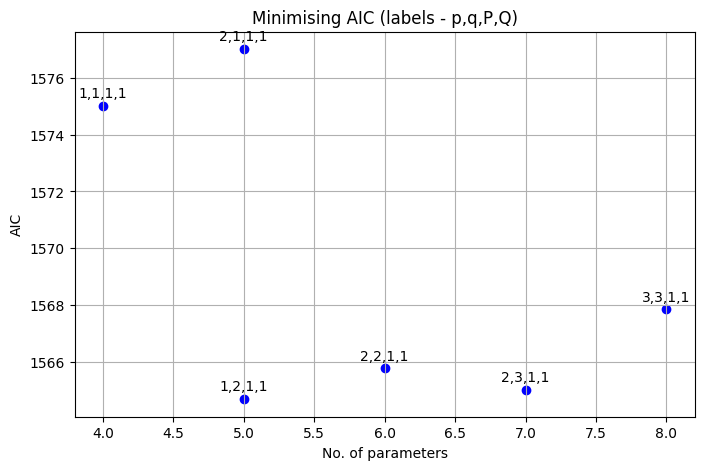

In [9]:
x_values = [4, 5, 5, 6, 8, 7]
y_values = [1575.004, 1564.693, 1577.004, 1565.777, 1567.852, 1565.028]

labels = [
    "1,1,1,1", "1,2,1,1", "2,1,1,1", "2,2,1,1", "3,3,1,1", "2,3,1,1"
]

plt.figure(figsize=(8, 5))
plt.scatter(x_values, y_values, color='blue')

for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), textcoords="offset points", xytext=(0, 6), ha='center')

plt.xlabel('No. of parameters')
plt.ylabel('AIC')
plt.title('Minimising AIC (labels - p,q,P,Q)')
plt.grid(True)
plt.show()

The plot above shows the optimal parameters which minimise AIC are **(p,d,q,P,D,Q) = (1,1,2,1,1,1)**. 

Below, the Q-Q plot of the residuals using these parameters shows a residual distribution which largely follows a normal distribution, with fat-tails. This suggests this SARIMA model has not fully captured the underlying structure of the data, particularly the extreme values or outliers. This is expected since no exogenous variables, like weather and public holidays, have yet been introduced.

                                       SARIMAX Results                                       
Dep. Variable:                             D.DS168.y   No. Observations:                  331
Model:             SARIMAX(1, 0, 2)x(1, 0, [1], 168)   Log Likelihood                -775.347
Date:                               Thu, 27 Feb 2025   AIC                           1564.693
Time:                                       17:01:56   BIC                           1591.308
Sample:                                   11-08-2019   HQIC                          1575.308
                                        - 11-21-2019                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0003      0.002     -0.140      0.889      -0.005       0.004
ar.L1      

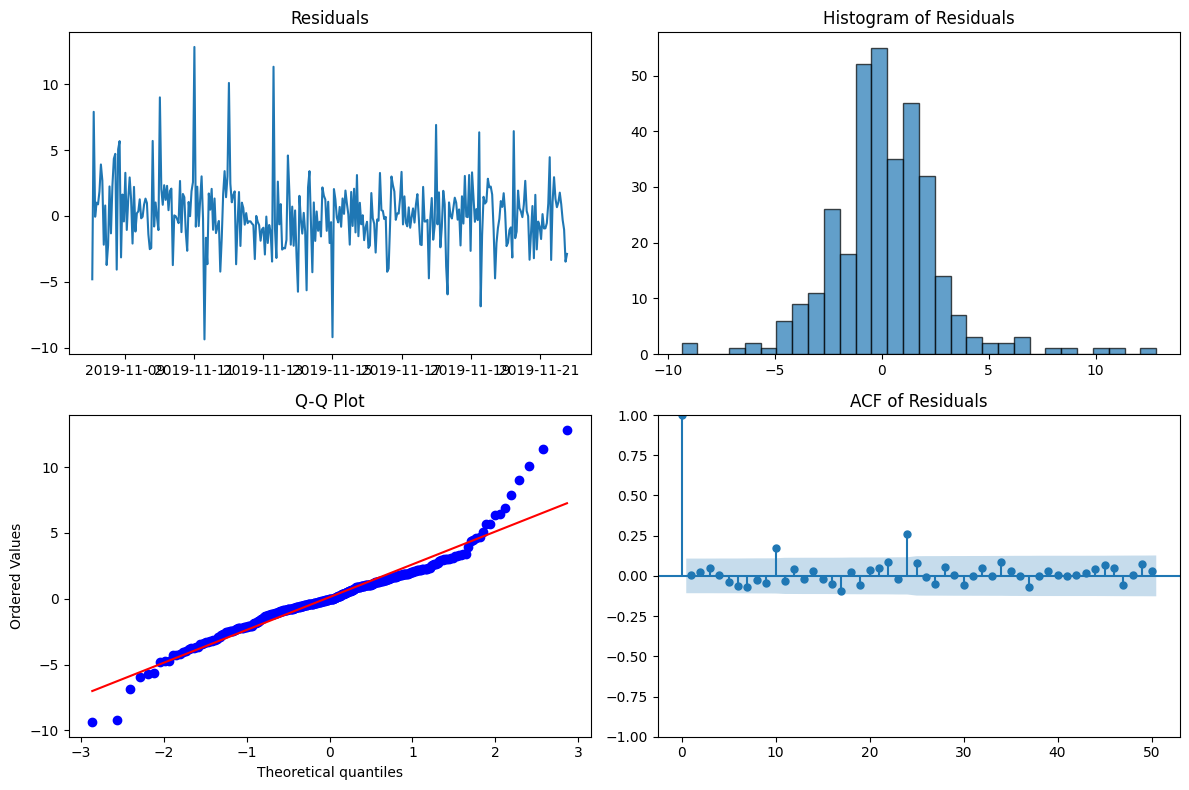

In [10]:
df_train = df.iloc[:500]

model = pmdarima.ARIMA(
            order=(1, 1, 2),  # (p, d, q)
            seasonal_order=(1, 1, 1, 24*7),  # (P, D, Q, s)
            suppress_warnings=True,
            simple_differencing=True
        )
model.fit(df_train['Energy Price (EUR/MWh)'])

print(model.summary())

residuals = model.resid()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot residuals
axes[0, 0].plot(residuals)
axes[0, 0].set_title("Residuals")

# Histogram of residuals
axes[0, 1].hist(residuals, bins=30, edgecolor="k", alpha=0.7)
axes[0, 1].set_title("Histogram of Residuals")

# Q-Q plot
probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot")

# ACF of residuals
plot_acf(residuals, lags=50, ax=axes[1, 1])
axes[1, 1].set_title("ACF of Residuals")

plt.tight_layout()
plt.show()


## Fitting the SARIMA Model

SARIMA models only allow predictions for time steps directly following the end of the data used to train the model. For example, if the 500 data points used to train the model end at 2024-01-01 12:00, then then model can only make predictions for 2024-01-01 13:00. It can then also use this prediction to make a further prediction for 2024-01-01 14:00 etc. Any error made in earlier predictions will propagate into later predictions. 

A work around for this limitation is creating a new model for new data (e.g. a later date), but using the same parameters as the previously trained model and specifying 0 optimisation iterations. Avoiding retraining the model greatly reduces the time to obtain the predictions.

This model needs to be able to predict the hourly demand for the next day by the time the day ahead market closes, so at 12:00. Therfore, the model will need to forecast 36 hours ahead; 12 hours to get to 00:00 and then 24 hours of day ahead predictions.

A rolling forecast is required to generate these predictions, with a new SARIMA model being fit for every 30 days in the test date range (2023-11-01 00:00 -> 2024-11-01 00:00). Each model will be fit using the 500 previous data points before 12:00 on the day from which the prediction is made. Using the work around allows the same model to be used for every date within each given 30 day period.

In [ ]:
# Parameters for SARIMA
order = (1, 1, 1)  # (p, d, q)
seasonal_order = (1, 1, 1, 24*7)  # (P, D, Q, s)

# Forecast Horizon (35 hours: 12 hours to get to midnight, plus 23 hours of predictions)
forecast_hours = 35

# List to store rolling forecast predictions
forecast_values = []

initial_prediction_date = pd.Timestamp('2023-10-31 12:00')

train_data = df[(df.index <= initial_prediction_date) & (df.index > initial_prediction_date - pd.Timedelta(hours=500))]

# Fit the SARIMA model to the training data
model = pmdarima.ARIMA(
        order=order,
        seasonal_order=seasonal_order,
        suppress_warnings=True, maxiter=10
    )
model.fit(train_data['Energy Price (EUR/MWh)'])

# print(model.summary())

# Make predictions
forecast = model.predict(n_periods = forecast_hours)
# Store the forecast values
forecast_values.extend(forecast[11:])


# Define the rolling forecast process for a year
for i in range(1, 366):
    print(i)

    # Determine the starting point of the training data (last 500 data points before the prediction day)
    train_data_end = initial_prediction_date + pd.Timedelta(days=i)

    if i % 30 == 0:

        train_data_start = train_data_end - pd.Timedelta(hours=500)
        
        # Create the training data slice for the current prediction day
        train_data = df[(df.index > train_data_start) & (df.index <= train_data_end)]

        model = pmdarima.ARIMA(
                order=order,
                seasonal_order=seasonal_order,
                suppress_warnings=True, maxiter=10
            )
        model.fit(train_data['Energy Price (EUR/MWh)'])
    
    else:

        train_data_start = train_data_end - pd.Timedelta(hours=169)
        
        # Create the training data slice for the current prediction day
        train_data = df[(df.index > train_data_start) & (df.index <= train_data_end)]

        model = pmdarima.ARIMA(
                order=order,
                seasonal_order=seasonal_order,
                suppress_warnings=True, maxiter=0, method = 'nm',
                start_params=model.params()
            )
        model.fit(train_data['Energy Price (EUR/MWh)'])

    # print(model.summary())

    # Make predictions
    forecast = model.predict(n_periods = forecast_hours)
    # Store the forecast values
    forecast_values.extend(forecast[11:])

predictions = pd.DataFrame(forecast_values, columns=['SARIMA Prediction'])
predictions.to_csv('data/price_prediction.csv', index=False)

The code above takes a significant amount of time to run, so the results are saved to `price_prediction.csv` for convenience.

In [ ]:
# Save predictions to new csv
predictions = pd.read_csv('data/price_prediction.csv')
df_test = df[(df.index >= '2023-11-01 00:00') & (df.index < '2024-11-01 00:00')]
forecast_values = predictions['SARIMA Prediction'].to_list()
df_test['SARIMA Prediction'] = forecast_values

output_df = df_test[['Energy Price (EUR/MWh)', 'SARIMA Prediction']].copy()
output_df.to_csv('data/price_prediction.csv', index=True)

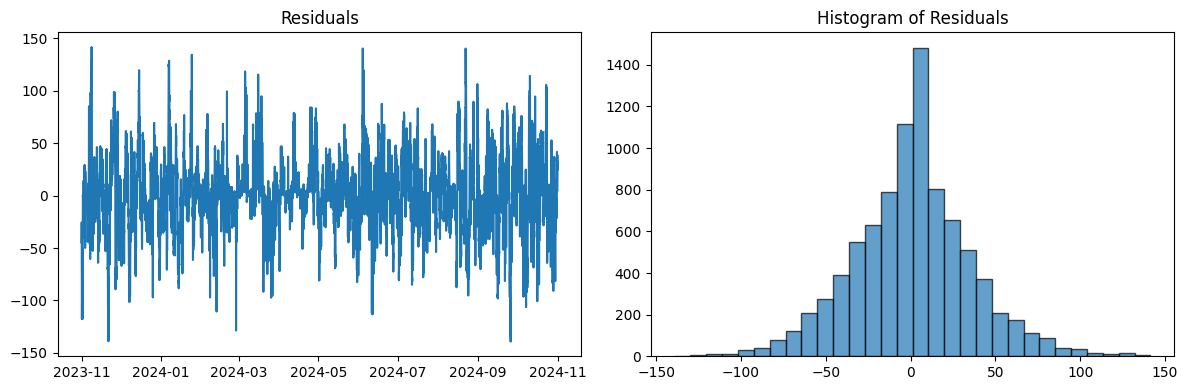

RMSE : 34.97
MAE : 26.08


In [11]:
predictions = pd.read_csv('data/price_prediction.csv')
predictions['datetime'] = pd.to_datetime(predictions['datetime'], errors='coerce')
predictions.set_index('datetime', inplace=True)

predictions['residuals'] = predictions['Energy Price (EUR/MWh)'] - predictions['SARIMA Prediction']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot residuals
axes[0].plot(predictions['residuals'])
axes[0].set_title("Residuals")

# Histogram of residuals
axes[1].hist(predictions['residuals'], bins=30, edgecolor="k", alpha=0.7)
axes[1].set_title("Histogram of Residuals")

plt.tight_layout()
plt.show()

rmse = np.sqrt(mean_squared_error(predictions['Energy Price (EUR/MWh)'], predictions['SARIMA Prediction']))
mae = mean_absolute_error(predictions['Energy Price (EUR/MWh)'], predictions['SARIMA Prediction'])

print(f'RMSE : {rmse:.2f}')
print(f'MAE : {mae:.2f}')

## Previous-Week Forecast Benchmark

Simple benchmarks which simply uses the energy demand from the previous week or day as a prediction for future energy price. Day-ahead predictions require predictions from 12:00 - 23:00 using data from two days ago as predictions are made at noon, so these later hours will not have occured yet. These will be compared to the SARIMA model's performance.

In [ ]:
# Generate predictions
df['prediction_week'] = df['Energy Price (EUR/MWh)'].shift(168)
df['prediction_day'] = np.where(df.index.hour > 12, 
                            df['Energy Price (EUR/MWh)'].shift(48), 
                            df['Energy Price (EUR/MWh)'].shift(24))
df_test = df[(df.index >= '2023-11-01 00:00') & (df.index < '2024-11-01 00:00')]

# Save _weeks to new csv
predictions = pd.read_csv('data/price_prediction.csv')
predictions['datetime'] = pd.to_datetime(predictions['datetime'], errors='coerce')
predictions.set_index('datetime', inplace=True)
predictions['Previous-Week Prediction'] = df_test['prediction_week']
predictions['Previous-Day Prediction'] = df_test['prediction_day']

predictions.to_csv('data/price_prediction.csv', index=True)

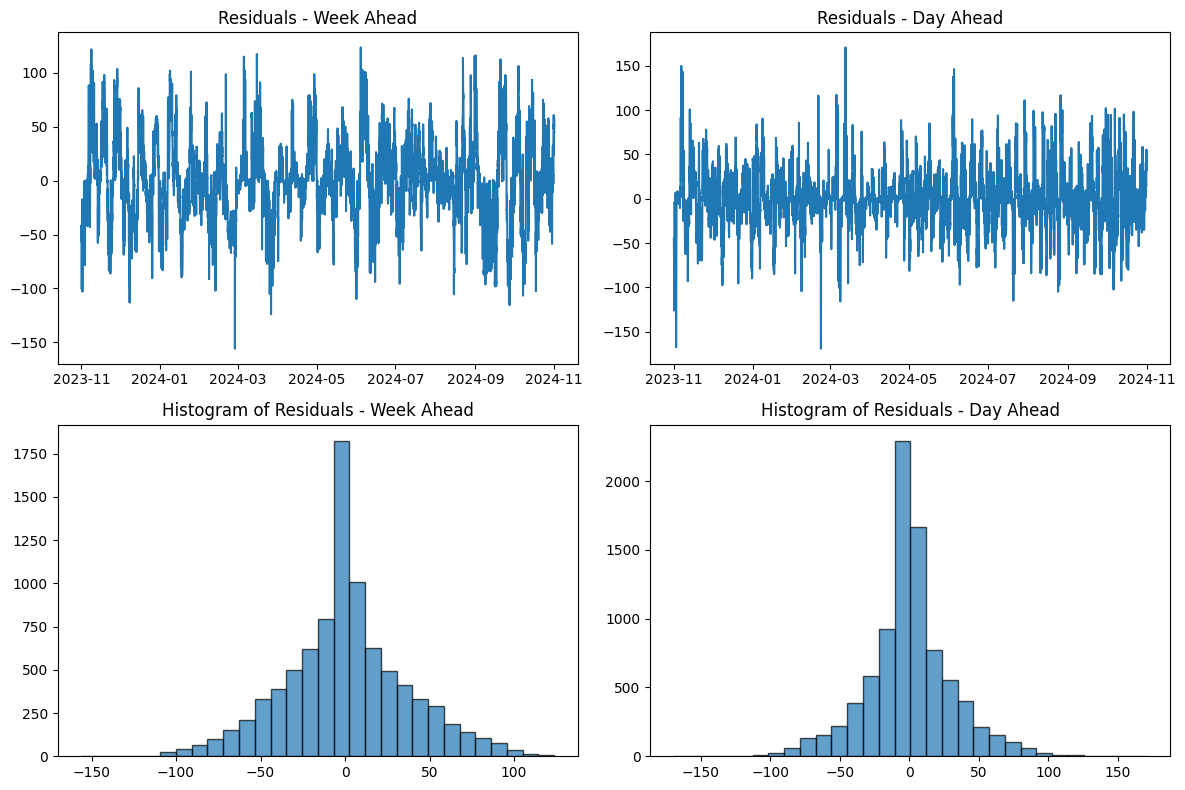

RMSE - Week Ahead: 35.89
MAE - Week Ahead: 26.34
RMSE - Day Ahead: 30.70
MAE - Day Ahead: 21.16


In [ ]:
predictions = pd.read_csv('data/price_prediction.csv')
predictions['datetime'] = pd.to_datetime(predictions['datetime'], errors='coerce')
predictions.set_index('datetime', inplace=True)

predictions['residuals_week'] = predictions['Energy Price (EUR/MWh)'] - predictions['Previous-Week Prediction']
predictions['residuals_day'] = predictions['Energy Price (EUR/MWh)'] - predictions['Previous-Day Prediction']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot residuals
axes[0][0].plot(predictions['residuals_week'])
axes[0][0].set_title("Residuals - Week Ahead")

# Histogram of residuals
axes[1][0].hist(predictions['residuals_week'], bins=30, edgecolor="k", alpha=0.7)
axes[1][0].set_title("Histogram of Residuals - Week Ahead")

# Plot residuals
axes[0][1].plot(predictions['residuals_day'])
axes[0][1].set_title("Residuals - Day Ahead")

# Histogram of residuals
axes[1][1].hist(predictions['residuals_day'], bins=30, edgecolor="k", alpha=0.7)
axes[1][1].set_title("Histogram of Residuals - Day Ahead")

plt.tight_layout()
plt.show()

rmse_week = np.sqrt(mean_squared_error(predictions['Energy Price (EUR/MWh)'], predictions['Previous-Week Prediction']))
mae_week = mean_absolute_error(predictions['Energy Price (EUR/MWh)'], predictions['Previous-Week Prediction'])
rmse_day = np.sqrt(mean_squared_error(predictions['Energy Price (EUR/MWh)'], predictions['Previous-Day Prediction']))
mae_day = mean_absolute_error(predictions['Energy Price (EUR/MWh)'], predictions['Previous-Day Prediction'])

print(f'RMSE - Week Ahead: {rmse_week:.2f}')
print(f'MAE - Week Ahead: {mae_week:.2f}')
print(f'RMSE - Day Ahead: {rmse_day:.2f}')
print(f'MAE - Day Ahead: {mae_day:.2f}')

## Summary

The SARIMA model, with a RMSE of 34.97 EUR/MWh, MAE of 26.08, performed worse in predicting energy demand compared to the simple previous-day forecast, which achieved a RMSE of 30.70 EUR/MWh, MAE of 21.16, but better than the previous-week forecast, which  achieved a RMSE of 35.89 EUR/MWh, MAE of 26.34. The day-ahead benchmark outperforming the week-ahead benchmark, unlike for predicting energy demand, is due to energy price being less seasonal than demand and being affected heavily by market structure, supply constraints, renewables availability, fuel costs, and short-term bidding behavior. The SARIMA model also struggled to capture the underlying patterns in the data effectively, possibly due to overfitting, misrepresentation of seasonal trends or its inability to model non-linear dynamics.

Therefore, the previous-day forecast will serve as a baseline benchmark for evaluating the performance of more advanced machine learning models. By establishing a simple, intuitive reference point, we can assess whether more complex models provide meaningful improvements in accuracy. Future efforts will focus on leveraging machine learning approaches, such as gradient boosting or neural networks, which are better equipped to capture non-linearities, interactions, and subtle temporal dynamics in the data. With these models, we aim to achieve a better fit and improve predictive performance, reducing the errors seen in both RMSE and MAE compared to the benchmark.